# Data Overview

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("D:/Công việc/DA + DE/Book DA/Data Science for Business/PaySim/fraud-detection-paysim\data/raw/Synthetic_Financial_datasets_log.csv")
data.head(5)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\admin\AppData\Local\Temp\ipykernel_16028\3529440422.py:1: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv("D:/Công việc/DA + DE/Book DA/Data Science for Business/PaySim/fraud-detection-paysim\data/raw/Synthetic_Financial_datasets_log.csv")


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
data.shape

(6362620, 11)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Insight 1: Sự lãng phí của kiểu dữ liệu mặc định (isFraud)
Mặc định, Pandas dùng int64 (8 bytes) cho cột isFraud. Nhưng chúng ta biết nó chỉ chứa 0 và 1.

Cách kiểm chứng:
Chúng ta sẽ so sánh dung lượng của cột này trước và sau khi ép về int8 (1 byte).

In [6]:
#1. Tính dung lượng hiện tại (đơn vị: Bytes)
original_size = data['isFraud'].memory_usage(index=False, deep=True)

In [7]:
# 2. Ép kiểu thử nghiệm
downcasted_isFraud = data['isFraud'].astype('int8')
new_size = downcasted_isFraud.memory_usage(index=False, deep=True)

In [8]:
print(f"Dung lượng ban đầu: {original_size/ 1024**2:.2f} MB")
print(f"Dung lượng sau khi tối ưu: {new_size / 1024**2:.2f} MB")
print(f"Tỷ lệ tiết kiệm: {(1- new_size/original_size)*100:.1f}%")

Dung lượng ban đầu: 48.54 MB
Dung lượng sau khi tối ưu: 6.07 MB
Tỷ lệ tiết kiệm: 87.5%


Insight 2: Tối ưu dựa trên dải giá trị thực tế (step)
Cột step đại diện cho số giờ. Trong dữ liệu đầy đủ, nó chỉ tới 743.

Cách kiểm chứng:
Chúng ta kiểm tra giá trị lớn nhất và xem nó có "vừa" với các kiểu dữ liệu nhỏ hơn không.

In [9]:
step_max = data['step'].max()
print(f"Giá trị lớn nhât của step: {step_max} ")

Giá trị lớn nhât của step: 743 


In [10]:
# Kiểm tra giới hạn của int16
import numpy as np
print(f"Giới hạn tối đa của int16: {np.iinfo(np.int16).max}")

Giới hạn tối đa của int16: 32767


Insight 3: Sai số khi dùng float32 cho giao dịch (amount)
Chúng ta sẽ xem liệu việc giảm độ chính xác có làm thay đổi số tiền đáng kể không.

Cách kiểm chứng:
Tính sự chênh lệch (sai số) giữa giá trị 64-bit và 32-bit.

In [11]:
# Tính sai số trung bình 
diff = (data['amount'] - data['amount'].astype('float32')).abs()
print(f"Sai số trung bình trên mỗi giao dịch: {diff.mean():.10f}")

Sai số trung bình trên mỗi giao dịch: 0.0037480100


In [12]:
import sys
sys.path.append('../')
from src.data_loader import load_paysim_data
df = load_paysim_data('D:/Công việc/DA + DE/Book DA/Data Science for Business/PaySim/fraud-detection-paysim/data/raw/Synthetic_Financial_datasets_log.csv')
df.info()

--- Đang tải dữ liệu từ: D:/Công việc/DA + DE/Book DA/Data Science for Business/PaySim/fraud-detection-paysim/data/raw/Synthetic_Financial_datasets_log.csv ---


Bộ nhớ tiêu thụ ban đầu: 533.97 MB
Bộ nhớ tiêu thụ sau tối ưu: 248.78 MB
Tiết kiệm được: 53.4%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int16   
 1   type            category
 2   amount          float32 
 3   nameOrig        object  
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        object  
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(1), float32(5), int16(1), int8(2), object(2)
memory usage: 248.8+ MB


Phân loại biến

| Tên cột          | Nhóm biến          | Loại dữ liệu phân tích           | Ý nghĩa                                   |
| ---------------- | ------------------ | -------------------------------- | ----------------------------------------- |
| `step`           | Thời gian          | Numerical (Discrete / Time-like) | Đơn vị thời gian mô phỏng giao dịch       |
| `type`           | Mô tả giao dịch    | Categorical                      | Loại giao dịch                            |
| `amount`         | Mô tả giao dịch    | Numerical (Continuous)           | Giá trị giao dịch                         |
| `nameOrig`       | Định danh thực thể | Identifier                       | Mã tài khoản / người gửi                  |
| `oldbalanceOrg`  | Số dư tài khoản    | Numerical (Continuous)           | Số dư trước giao dịch của tài khoản nguồn |
| `newbalanceOrig` | Số dư tài khoản    | Numerical (Continuous)           | Số dư sau giao dịch của tài khoản nguồn   |
| `nameDest`       | Định danh thực thể | Identifier                       | Mã tài khoản / người nhận                 |
| `oldbalanceDest` | Số dư tài khoản    | Numerical (Continuous)           | Số dư trước giao dịch của tài khoản đích  |
| `newbalanceDest` | Số dư tài khoản    | Numerical (Continuous)           | Số dư sau giao dịch của tài khoản đích    |
| `isFraud`        | Nhãn / mục tiêu    | Binary / Target                  | Biến mục tiêu xác định giao dịch gian lận |
| `isFlaggedFraud` | Nhãn / cảnh báo    | Binary Indicator                 | Cờ cảnh báo gian lận do hệ thống gắn      |


# Kiểm tra chất lượng dữ liệu

In [13]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

# Phân tích đơn biến

## Nhóm thời gian

Cột step

In [15]:
print(df['step'].describe().apply(lambda x: format(x, 'f')))

count    6362620.000000
mean         243.397246
std          142.331971
min            1.000000
25%          156.000000
50%          239.000000
75%          335.000000
max          743.000000
Name: step, dtype: object


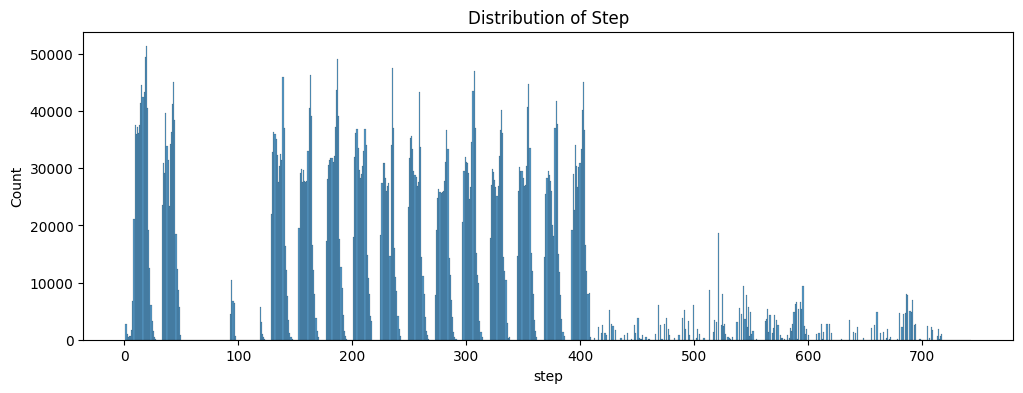

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
sns.histplot(df['step'], bins=743)
plt.title('Distribution of Step')
plt.show()

Từ biểu đồ ta thấy

1.Tính chu kỳ: Dữ liệu không dàn đều mà tạo thành các cụm giao dịch cao điểm, đan xen là những khoảng trũng rất sâu, nơi lượng giao dịch tụt xuống mức cực thấp.

2.Sự sụt giảm cấu trúc: Nửa đầu của biểu đồ (từ step 0 đến khoảng step 400) diễn ra vô cùng sôi động với hàng trăm ngàn giao dịch mỗi giờ. Tuy nhiên, kể từ sau khoảng step 400 (tương đương ngày thứ 16), lượng giao dịch sụt giảm một cách đột ngột và chỉ duy trì ở mức lác đác cho đến hết tháng.

Những "khoảng trũng" lặp đi lặp lại một cách đều đặn giữa các cụm giao dịch cao điểm kia đang phản ánh thực tế hành vi nào của người dùng? --> tính chu kỳ

Cụ thể hơn, những khoảng trũng sâu lặp đi lặp lại đó phản ánh chu kỳ sinh học bình thường của con người (Day/Night cycle). Đó chính là khoảng thời gian ban đêm (thường từ 1h đến 5h sáng), khi hầu hết người dùng đang ngủ và các hoạt động kinh tế cá nhân tạm dừng.

--> Nhóm giao dịch bình thường (chiếm đại đa số dữ liệu) bắt buộc phải tuân theo chu kỳ sinh hoạt này. Khối lượng giao dịch sẽ từ từ tăng lên vào buổi sáng, đạt đỉnh vào ban ngày và hạ nhiệt vào ban đêm.

Nếu tách riêng các vụ Gian lận (isFraud = 1) ra và vẽ lên biểu đồ 24 giờ, phân phối của nhóm gian lận có bị "trũng xuống" vào ban đêm giống như người bình thường không? --> hour + isFraud 

## Nhóm mô tả giao dịch


Cột type

In [17]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

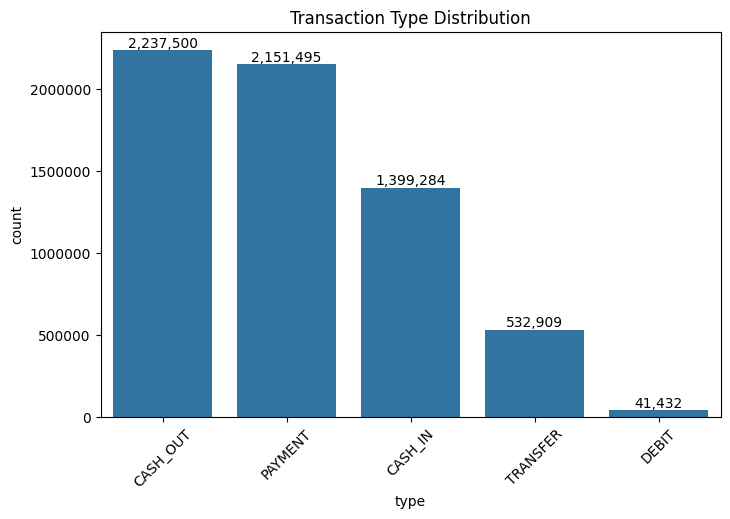

In [18]:
plt.figure(figsize=(8,5))
ax= sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.ticklabel_format(style= 'plain', axis= 'y') # tắt scientific notation
for p in ax.patches:
    height= int(p.get_height())
    ax.annotate(
        f'{height:,}',
        (p.get_x() + p.get_width() /2, height),
        ha='center',
        va='bottom'
    )
plt.title("Transaction Type Distribution")
plt.xticks(rotation=45)
plt.show()

In [19]:
df['type'].value_counts(normalize=True) * 100

type
CASH_OUT    35.166331
PAYMENT     33.814608
CASH_IN     21.992261
TRANSFER     8.375622
DEBIT        0.651178
Name: proportion, dtype: float64

Sự áp đảo của giao dịch CASH_OUT và PAYMENT cho thấy nền tảng này hoạt động như một ví điện tử tiêu dùng vi mô, hơn là một cổng đầu tư tài chính.

Tuy nhiên, nếu đứng dưới góc độ của một tội phạm tài chính, mục đích cuối cùng của việc hack tài khoản không phải là để... trả hộ tiền điện (PAYMENT). Mục tiêu của chúng là tẩu tán tài sản nhanh nhất và biến tiền ảo thành tiền mặt thật. Do đó, chúng ta đặt giả thuyết rằng: Hành vi gian lận (isFraud) sẽ không phân bố đều trên tất cả các loại hình giao dịch, mà sẽ tập trung cục bộ vào các phương thức giúp chúng 'hạ cánh' an toàn --> type + isFraud

Cột amount

In [20]:
df['amount'].describe().apply(lambda x: format(x, 'f'))

count     6362620.000000
mean       179861.890625
std        603858.250000
min             0.000000
25%         13389.570312
50%         74871.937500
75%        208721.480469
max      92445520.000000
Name: amount, dtype: object

Ta thấy mean lớn gấp khoảng 2.4 lần 50% cho thấy quy luật phân phối Pareto (80/20), cho thấy giao dịch nhỏ lẻ chiếm phần lớn đã kéo mean xuống' và std cao gấp khoảng 3.35 lần mean cho thấy có hai thành phần chính: người nghèo (giao dịch vài đồng) và siêu giàu/doanh nghiệp (giao dịch rất lớn).

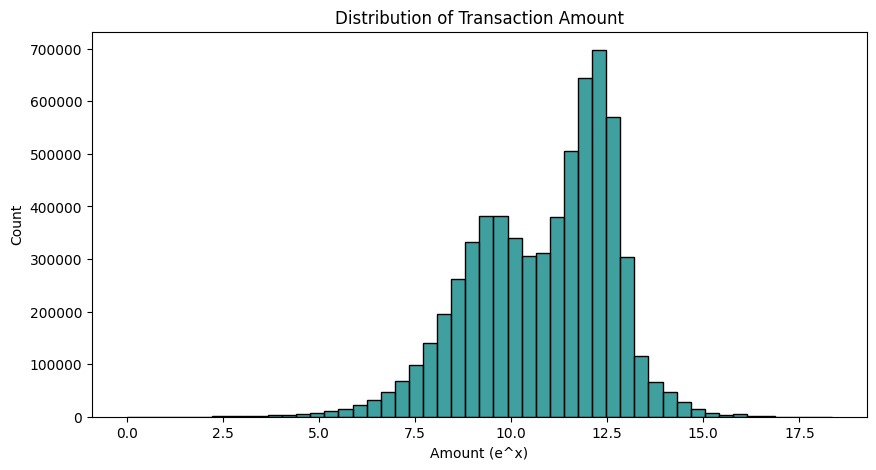

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(x=np.log1p(df['amount']), bins=50, color= 'teal') # log_scale=True sẽ tự động tính toán kích thước bins trên thang đo logarit
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount (e^x)")
plt.ylabel("Count")
plt.show()

Sau khi dùng log1p để khắc phục phân phối lệch phải ta thấy được có 2 đỉnh; đỉnh 1 tập trung vùng e^9.5-e^10 (~13k-22k USD) cho thấy dòng tiền luân chuyển liên tục nhưng giá trị nhỏ (payment); đỉnh 2 tập trung vùng e^12-e^12.5 (~162k-268k USD) cho thấy sự áp đảo về số lượng (đóng góp của cash-out và transfer) 

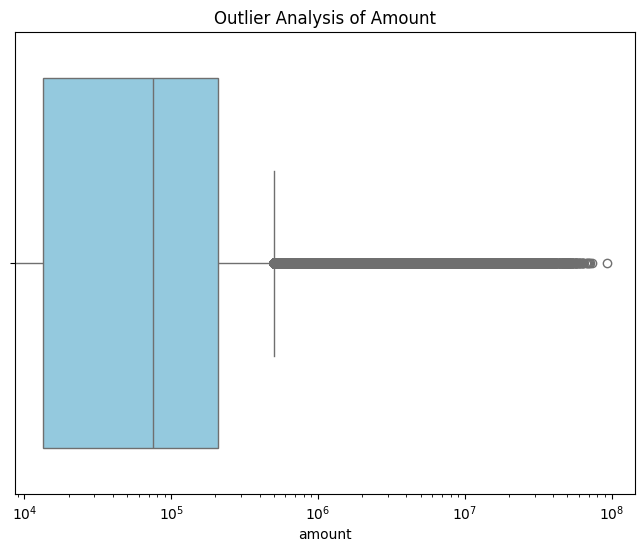

In [22]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['amount'], color= 'skyblue')
plt.xscale('log')
plt.title('Outlier Analysis of Amount')
plt.show()

In [23]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound= Q3 + 1.5 * IQR

In [24]:
outliers = df[df['amount'] > upper_bound]
print(f"Count amount outlier: {len(outliers)}")
print(f"Persen ourlier: {len(outliers)/len(df)*100:.2f}%")

Count amount outlier: 338078
Persen ourlier: 5.31%


Vì tỷ lệ ngoại lai là 5.31% --> có sự phân hóa giàu nghèo cực lớn, cần chú ý đến phần ngoại lai vì đa phần các vụ gian lận sẽ xảy ra ở đây để rút tiền được nhiều nhất có thể.

C:\Users\admin\AppData\Local\Temp\ipykernel_16028\2128605927.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='amount_segment', palette='viridis')


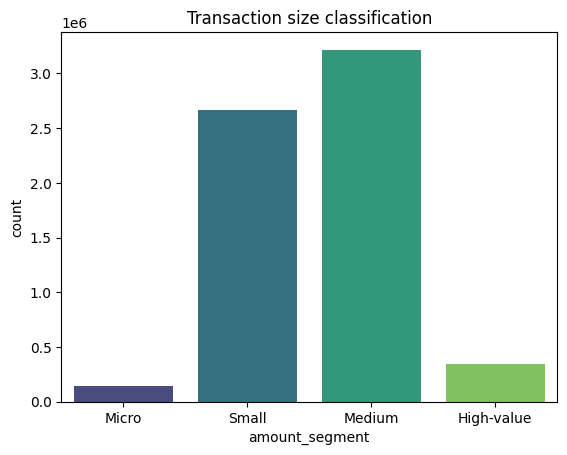

In [25]:
bins = [0, 1000, 50000, 500000, float('inf')] # ngưỡng chi tiêu
labels = ['Micro', 'Small', 'Medium', 'High-value']
df['amount_segment'] = pd.cut(df['amount'], bins=bins, labels=labels)
sns.countplot(data=df, x='amount_segment', palette='viridis')
plt.title('Transaction size classification')
plt.show()

Ta thấy nhóm nhỏ và trung bình chiếm đa số, đây là tệp khách hàng cá nhân đóng góp và sự số động của hệ thống nhưng biên lợi nhuận trên mỗi giao dịch thấp, nhóm lớn số lượng ít nhưng chiếm tỷ trọng lớn trong tổng dòng tiền luân chuyển --> Gian lận có tập trung 100% vào nhóm High-value không, hay chúng lẻn vào nhóm Medium để tránh các ngưỡng kiểm soát tự động của ngân hàng? --> amount + isFraud

## Nhóm định danh


Cột nameOrig

In [26]:
# Có bao nhiêu người gửi duy nhất 
df['nameOrig'].nunique()

6353307

In [27]:
# lấy 10 tài khoản thực hiện gửi tiền nhiều nhất
df['nameOrig'].value_counts().head(10)

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

In [28]:
df['nameOrig'].value_counts().describe().apply(lambda x: format(x, 'f'))

count    6353307.000000
mean           1.001466
std            0.038320
min            1.000000
25%            1.000000
50%            1.000000
75%            1.000000
max            3.000000
Name: count, dtype: object

Ta thấy trung bình mỗi người chỉ giao dịch 1 lần và cao nhất là 3 lần. Điều này khớp với mô hình ví điện tử cá nhân.

Cột nameDest

In [29]:
# Có bao nhiêu người gửi duy nhất 
df['nameDest'].nunique()

2722362

In [30]:
# lấy 10 tài khoản thực hiện nhận tiền nhiều nhất
df['nameDest'].value_counts().head(10)

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

Ta cần kiểm tra kĩ xem các tài khoản cá nhân này nhận tiền từ hàng trăm người có phải là giao dịch thật hay có sự bất thường (điểm thu gom lừa đảo hoặc tài khoản trung gian rửa tiền)

In [31]:
# 3. Phân loại Merchant vs Customer (Dựa trên ký tự đầu tiên)
df['dest_type'] = df['nameDest'].str[0]
dest_counts = df['dest_type'].value_counts(normalize=True) * 100
print("\nTỷ lệ loại tài khoản nhận tiền (%):")
print(dest_counts)


Tỷ lệ loại tài khoản nhận tiền (%):
dest_type
C    66.185392
M    33.814608
Name: proportion, dtype: float64


Ta thấy khoảng 66% người nhận là Customer, và 33.8% ngời nhận là Merchant

Phân tích đơn biến về định danh người nhận (nameDest) cho thấy một cấu trúc tập trung bất thường. Mặc dù Merchant chiếm gần 34% mạng lưới, nhưng Top 10 tài khoản nhận lưu lượng giao dịch lớn nhất (trên 100 lần) hoàn toàn thuộc về nhóm khách hàng cá nhân (Customer). Điều này đặt ra một nghi vấn lớn về hành vi: Tại sao các tài khoản cá nhân lại có lưu lượng nhận tiền tương đương với một tổ chức kinh tế? Liệu đây là các đại lý thanh khoản hợp pháp hay là các 'nút thắt' (hubs) trong một mạng lưới tẩu tán tài sản bất chính? Chúng tôi sẽ dùng biến isFraud ở phần sau để bóc tách bản chất của các siêu tài khoản này

## Nhóm số dư

Cột oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest

In [32]:
balance_cols = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

for col in balance_cols:
    print(f"\n---{col}---")
    print(df[col].describe().apply(lambda x: format(x, 'f')))
    print(f"Zero value: {(df[col] == 0).sum()} ({(df[col] == 0).mean()*100:.2f}%)")


---oldbalanceOrg---
count     6362620.000000
mean       833883.125000
std       2888242.750000
min             0.000000
25%             0.000000
50%         14208.000000
75%        107315.175781
max      59585040.000000
Name: oldbalanceOrg, dtype: object
Zero value: 2102449 (33.04%)

---newbalanceOrig---
count     6362620.000000
mean       855113.625000
std       2924048.500000
min             0.000000
25%             0.000000
50%             0.000000
75%        144258.406250
max      49585040.000000
Name: newbalanceOrig, dtype: object
Zero value: 3609566 (56.73%)

---oldbalanceDest---
count      6362620.000000
mean       1100701.750000
std        3399180.250000
min              0.000000
25%              0.000000
50%         132705.664062
75%         943036.687500
max      356015904.000000
Name: oldbalanceDest, dtype: object
Zero value: 2704388 (42.50%)

---newbalanceDest---
count      6362620.000000
mean       1224996.375000
std        3674129.000000
min              0.000000
25%    

Ta thấy oldablanceDest == 0 lên tới 42.5%, một tỷ lê rất cao cứ 10 tài khoản thì già 4 tài khoản là tài khoản mới hoặc tài khoản rác --> đây là cơ sở xác định rủi ro khi hệ thống có bị lợi dụng để tẩu tán tiền nhanh khi đang cho phép dòng tiền lớn đổ vào những tài khoản chưa có lịch sử tích lũy tài sản.

Kết quả này đặt ra yêu cầu phải phân tích đa biến ở chương sau để kiểm chứng liệu các tài khoản 'không lịch sử' này có phải là đích đến của hành vi gian lận (isFraud) hay không.

## Nhóm nhãn

Cột isFraud

In [33]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [34]:
df['isFraud'].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

Biến mục tiêu isFraud cho thấy dữ liệu bị mất cân bằng lớp nghiêm trọng, với số lượng giao dịch gian lận chiếm tỷ lệ rất nhỏ so với tổng số quan sát.

Cột IsFlaggedFraud

In [35]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

Ta thấy chỉ bắt được đúng 16 vụ trên tổng số 6.3 triệu giao dịch

In [36]:
df['isFlaggedFraud'].value_counts(normalize=True) * 100

isFlaggedFraud
0    99.999749
1     0.000251
Name: proportion, dtype: float64

Hệ thống rule-based cũ kỹ của ngân hàng hiện tại (isFlaggedFraud) hoàn toàn tê liệt, tỷ lệ bỏ lọt tội phạm (False Negative) gần như 100%. Đây là lý do cốt lõi phải xây dựng mô hình Machine Learning thay thế.

## Phân tích hai biến

hour vs isFraud

In [37]:
# Đổi 744 steps về khung giờ (0-23)
df['hour_of_day'] = df['step'] % 24
print("Khung giờ:",df['hour_of_day'].unique())

Khung giờ: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23  0]


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

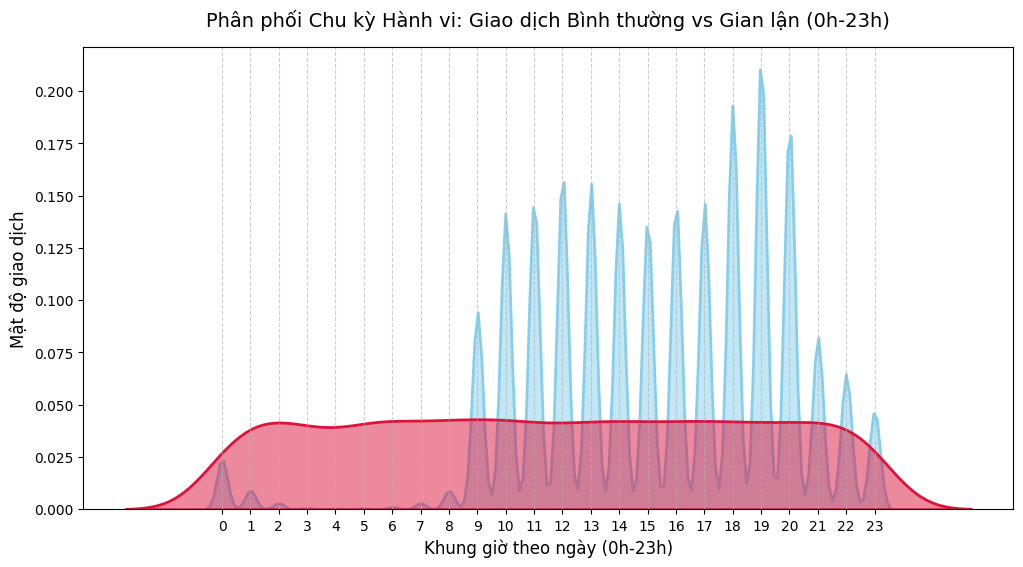

In [39]:
plt.figure(figsize=(12,6))

# Đường phân phối cho giao dịch bình thường
sns.kdeplot(data=df[df['isFraud'] == 0],
            x='hour_of_day', label='Giao dịch bình thường (isFraud=0)',
            fill=True, color='skyblue', alpha=0.5, linewidth=2)

# Đường phân phối cho giao dịch gian lận
sns.kdeplot(data=df[df['isFraud'] == 1],
            x='hour_of_day', label='Giao dịch gian lận (isFraud=1)',
            fill=True, color='crimson', alpha=0.5, linewidth=2)

plt.title('Phân phối Chu kỳ Hành vi: Giao dịch Bình thường vs Gian lận (0h-23h)', fontsize=14, pad=15)
plt.xlabel('Khung giờ theo ngày (0h-23h)', fontsize=12)
plt.ylabel('Mật độ giao dịch', fontsize=12)
plt.xticks(range(0,24))
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


Ta thấy được đường màu đỏ vẫn duy trì độ cao đè lên đường màu xanh --> ta có thể cho rằng: gian lận tài chính trên nền tảng này sử dụng công cụ tự động hóa (bot) để hoạt động bất chấp chu ký sinh học.

type vs isFraud

In [40]:
# Thống kê số lượng và tỷ lệ gian lận theo từng loại giao dịch
type_fraud_stats = df.groupby('type')['isFraud'].agg(['count','sum'])
type_fraud_stats.columns = ['Tổng số giao dịch', 'Số vụ gian lận']
type_fraud_stats['Tỷ lệ gian lận (%)'] = (type_fraud_stats['Số vụ gian lận'] / type_fraud_stats['Tổng số giao dịch']) * 100

print (type_fraud_stats.sort_values(by='Số vụ gian lận', ascending=False))

C:\Users\admin\AppData\Local\Temp\ipykernel_16028\52720761.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_fraud_stats = df.groupby('type')['isFraud'].agg(['count','sum'])


          Tổng số giao dịch  Số vụ gian lận  Tỷ lệ gian lận (%)
type                                                           
CASH_OUT            2237500            4116            0.183955
TRANSFER             532909            4097            0.768799
CASH_IN             1399284               0            0.000000
DEBIT                 41432               0            0.000000
PAYMENT             2151495               0            0.000000


---Đã tạo tập dữ liệu mẫu EDA: 32852 dòng ---


C:\Users\admin\AppData\Local\Temp\ipykernel_16028\3762890051.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_counts = balanced_df.groupby(['type','isFraud']).size().unstack(fill_value=0)


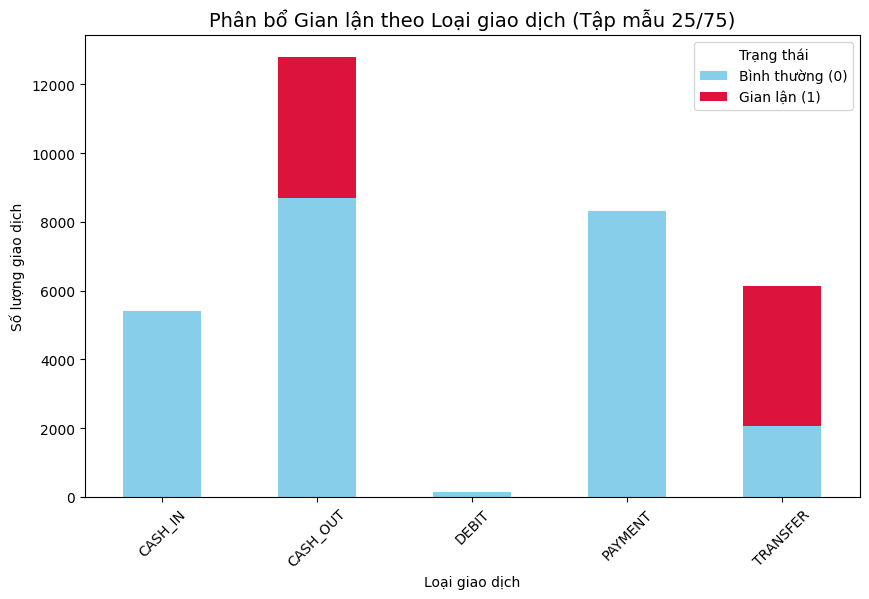

In [41]:
plt.figure(figsize=(10,6))

import sys
sys.path.append('../')
from src.data_loader import get_sample_data
balanced_df = get_sample_data(df)

fraud_counts = balanced_df.groupby(['type','isFraud']).size().unstack(fill_value=0)
fraud_counts.plot(kind='bar',stacked=True, color=['skyblue','crimson'], ax=plt.gca())

plt.title('Phân bổ Gian lận theo Loại giao dịch (Tập mẫu 25/75)', fontsize=14)
plt.xlabel('Loại giao dịch')
plt.ylabel('Số lượng giao dịch')
plt.legend(['Bình thường (0)', 'Gian lận (1)'], title='Trạng thái')
plt.xticks(rotation=45)
plt.show()

Kết quả phân tích hai biến cho thấy một mô hình gian lận có tính chọn lọc cực cao. Trong khi hệ thống xử lý 5 loại hình giao dịch khác nhau, rủi ro gian lận (isFraud=1) lại khu trú hoàn toàn (100%) trong hai phân khúc: TRANSFER (Chuyển khoản) và CASH_OUT (Rút tiền mặt)

Việc xác nhận gian lận chỉ tồn tại ở hai loại hình này cho phép áp dụng chiến lược 'Lọc rủi ro tập trung'. Thay vì huấn luyện mô hình trên toàn bộ tập dữ liệu gốc, nghiên cứu sẽ chỉ tập trung vào các giao dịch TRANSFER và CASH_OUT. Điều này giúp tăng cường độ nhạy của thuật toán (Sensitivity) và giảm thiểu sai số do nhiễu từ hơn 4 triệu giao dịch an toàn (như PAYMENT hay CASH_IN), vốn mang những đặc tính hành vi hoàn toàn khác biệt.

-->Tạo một hàm lấy mẫu lọc rủi ro tập trung + lấy mẫu 

amount vs isFraud

In [65]:
# Tính toán thống kê
stats = df.groupby('isFraud')['amount'].agg(['mean', 'median', 'max', 'min'])
print(stats)

                 mean        median         max   min
isFraud                                              
0        1.781970e+05   74684.71875  92445520.0  0.01
1        1.467967e+06  441423.43750  10000000.0  0.00


C:\Users\admin\AppData\Local\Temp\ipykernel_16028\3803452131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=balanced_df, x='isFraud', y='amount', ax=ax[0], palette= 'Set2')
C:\Users\admin\AppData\Local\Temp\ipykernel_16028\3803452131.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Bình thương (0)', 'Gian lận (1)'])


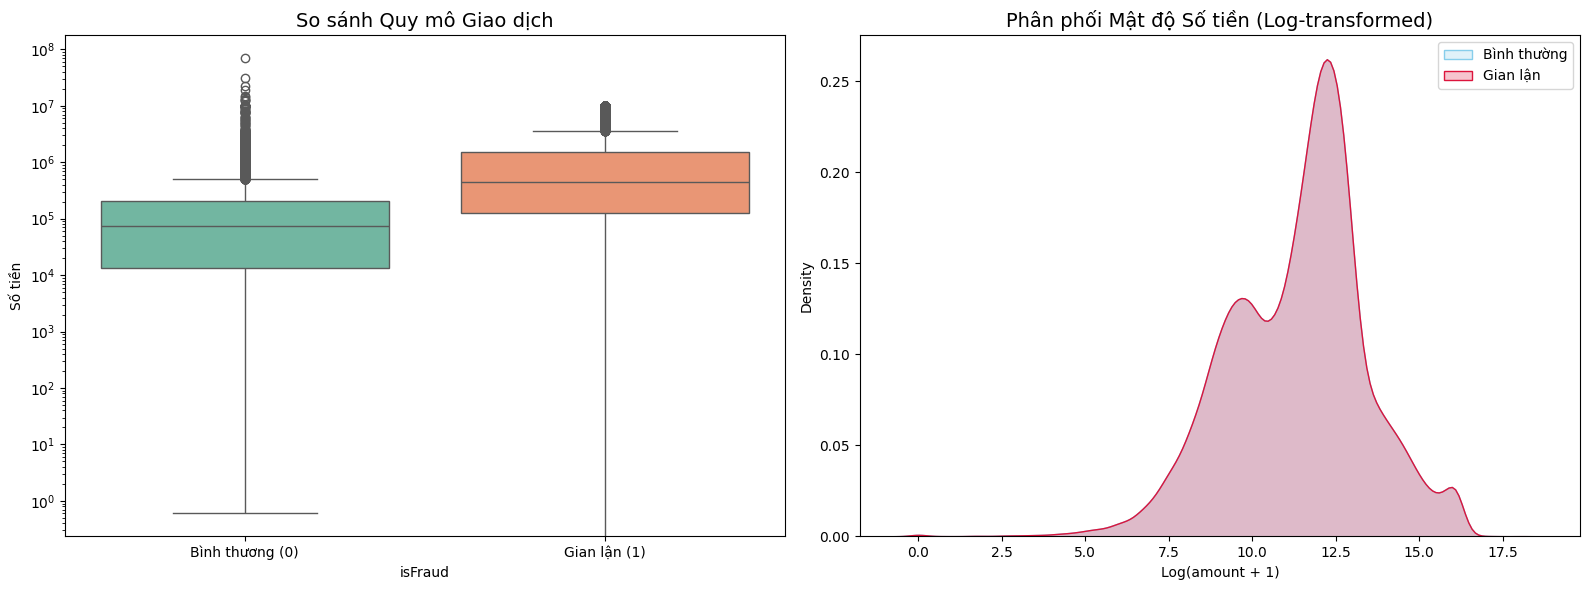

In [66]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Dùng boxplot có sử dụng Log-scale để thấy rõ Outliers
sns.boxplot(data=balanced_df, x='isFraud', y='amount', ax=ax[0], palette= 'Set2')
ax[0].set_yscale('log')
ax[0].set_title('So sánh Quy mô Giao dịch', fontsize=14)
ax[0].set_xticklabels(['Bình thương (0)', 'Gian lận (1)'])
ax[0].set_ylabel('Số tiền')

# KDE Plot 
sns.kdeplot(data=balanced_df[balanced_df['isFraud'] == 0], x=np.log1p(balanced_df['amount']),
            label='Bình thường', fill=True, ax=ax[1], color='skyblue')
sns.kdeplot(data=balanced_df[balanced_df['isFraud'] == 1], x=np.log1p(balanced_df['amount']), 
            label='Gian lận', fill=True, ax=ax[1], color='crimson')
ax[1].set_title('Phân phối Mật độ Số tiền (Log-transformed)', fontsize=14)
ax[1].set_xlabel('Log(amount + 1)')
ax[1].legend()

plt.tight_layout()
plt.show()

Nhìn vào biểu đồ boxplot ta thấy đường gạch giữa nhóm gian lận cao hơn hẳn so với nhóm bình thường, vad có một dải giá trị rất dày ở mức cao, nhưng có vẻ dừng lại ở một ngưỡng nào đó --> tội phạm không tập trung vào giao dịch nhỏ lẻ, mục tiêu là tối đa hóa lợi nhuận trong một lần thực thi bằng cách chuyển đi một con số tối đa có thể.

Nhìn vào biểu đồ KDE cho thấy nhóm gian lận có hình dạng mũi nhọn và tập trung ở mức cao, đây có thể là những dấu hiệu gian lận rất đặc trưng về số tiền

Tuy nhiên, nếu chỉ dựa vào số tiền lớn để báo động, ngân hàng sẽ đối mặt với tỷ lệ báo động giả (False Positive) rất cao đối với các khách hàng VIP. Do đó, chúng ta cần kết hợp thêm Logic số dư (Balance Logic) để xác định xem số tiền lớn đó có tương xứng với tiềm lực tài chính của chủ tài khoản hay không.

dest_type vs isFraud

In [75]:
# Trích xuất loại tài khoản đích: 'C' or 'M'
# Lấy ký tự đầu tiên của cột nameDest
balanced_df['dest_type'] = balanced_df['nameDest'].str[0]
balanced_df['dest_type'] = balanced_df['dest_type'].map({'C': 'Customer (C)', 'M': 'Merchant (M)'})

In [76]:
# Thống kê số lượng và tỷ lệ
dest_fraud_stats = pd.crosstab(balanced_df['dest_type'], balanced_df['isFraud'], normalize='index') *100
print(dest_fraud_stats)

isFraud                0          1
dest_type                          
Customer (C)   66.513088  33.486912
Merchant (M)  100.000000   0.000000


Như vậy gian lận tập trung toàn bộ ở nhóm Customer do thấy lỗ hổng nằm ở cơ chế quản lý tài khoản cá nhân. Đây là căn cứ để nghiên cứu đề xuất việc thắt chặt hạn mức giao dịch (Limit management) dựa trên loại thực thể nhận tiền thay vì áp dụng một hạn mức chung cho toàn hệ thống.

Dựa trên bằng chứng thực nghiệm rằng 100% hành vi gian lận chỉ hướng tới các tài khoản cá nhân (Customer), chúng ta lại đã thực hiện bước Tối ưu hóa dữ liệu huấn luyện (Training Data Optimization). Cụ thể, trong hàm lấy mẫu cho mô hình (get_sample_modeling), thiết lập bộ lọc Whitelist để loại bỏ hoàn toàn các giao dịch hướng tới tổ chức/cửa hàng (Merchant). Việc 'làm sạch' này giúp mô hình tập trung học các đặc trưng tinh vi của dòng tiền P2P (Peer-to-Peer), nơi tội phạm đang thực sự hoạt động, thay vì bị nhiễu bởi các giao dịch thương mại hợp pháp.

oldbalanceDest vs isFraud

In [72]:
# Tạo biến phân loại: có lịch sử số dư hay không
balanced_df['dest_has_history'] = balanced_df['oldbalanceDest'].apply(lambda x: 'Có lịch sử (>0)' if x > 0 else 'Trắng (0.0)')

In [73]:
# Tính tỷ lệ gian lận trong từng nhóm
history_stats = pd.crosstab(balanced_df['dest_has_history'], balanced_df['isFraud'],normalize='index') * 100
print(history_stats)

isFraud                   0          1
dest_has_history                      
Có lịch sử (>0)   83.177570  16.822430
Trắng (0.0)       66.216302  33.783698


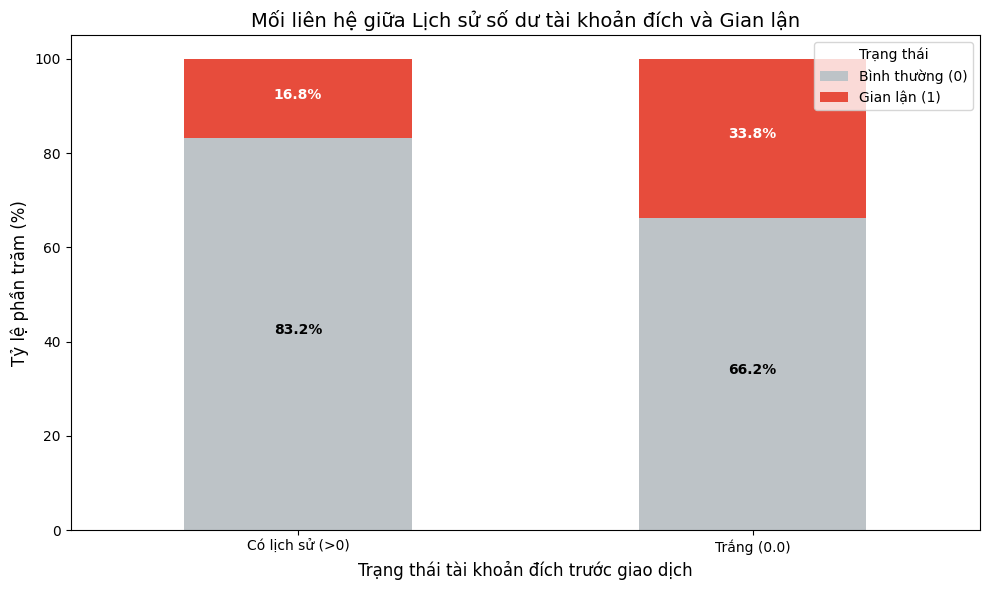

In [74]:
plt.figure(figsize=(10,6))
history_stats.plot(kind='bar', stacked=True, color=['#bdc3c7', '#e74c3c'], ax=plt.gca())

plt.title('Mối liên hệ giữa Lịch sử số dư tài khoản đích và Gian lận', fontsize=14)
plt.xlabel('Trạng thái tài khoản đích trước giao dịch', fontsize = 12)
plt.ylabel('Tỷ lệ phần trăm (%)', fontsize=12)
plt.legend(['Bình thường (0)', 'Gian lận (1)'], loc='upper right', title='Trạng thái')
plt.xticks(rotation=0)

for i, (idx, row) in enumerate(history_stats.iterrows()):
    plt.text(i, row[0]/2, f"{row[0]:.1f}%", ha='center', color='black', fontweight='bold')
    plt.text(i, row[0] + row[1]/2, f"{row[1]:.1f}%", ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Ta có thể thấy tài khoản trắng (số dư = 0) tỉ lệ gian lận cao hơn nhiều so với tài khoản có lịch sử (sô dư > 0), có thể cho thấy một chiến thuật tẩu tán có tổ chức.

--> Ngân hàng nên áp dụng cơ chế 'Quản chế' (Probation Period) cho tài khoản mới hoặc tài khoản đã lâu không hoạt động. Mọi giao dịch giá trị lớn đổ vào tài khoản có số dư bằng 0 cần bị trì hoãn (Hold) trong 24h để xác minh danh tính.

--> Nếu thấy oldbalanceDest == 0 và newbalanceDest == 0 (mặc dù có nhận tiền), đây chính là bằng chứng của việc tội phạm thực hiện giao dịch "vòng" hoặc lỗi hệ thống ghi nhận có ý đồ --> Logic kế toán có điểm mù --> isFraud + orig_error + dest_error

isFlaggedFraud + type và isFlaggedFraud + amount

In [49]:
min_amount_flagged = df[df['isFlaggedFraud'] == 1]['amount'].min()
types_flagged = df[df['isFlaggedFraud'] == 1]['type'].unique()

print(f"Số tiền nhỏ nhất bị hệ thống cũ bắt: {min_amount_flagged:,.0f}")
print(f"Các loại giao dịch bị hệ thống cũ bắt: {types_flagged}")

Số tiền nhỏ nhất bị hệ thống cũ bắt: 353,874
Các loại giao dịch bị hệ thống cũ bắt: ['TRANSFER']
Categories (5, object): ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']


Thông qua việc đối soát giữa biến isFlaggedFraud và các biến amount và type, ta đã thực hiện phép lọc trên nhóm giao dịch bị cảnh báo để truy tìm quy tắc cốt lõi của hệ thống hiện hành. Kết quả cho thấy một ngưỡng lọc tĩnh được thiết lập ở mức 353,874 đơn vị tiền tệ và chỉ bị bắt khi dùng loại TRANSFER

# Phân tích đa biến


Biến: isFraud + type + amount:Tìm xem bọn tội phạm tham lam nhất ở khâu nào? Khâu chuyển tiền (Transfer) hay khâu rút tiền (Cash_out)?


In [50]:
# Thống kê mô tả
fraud_only = balanced_df[balanced_df['isFraud'] == 1]
greed_stats = fraud_only.groupby('type')['amount'].agg(['count', 'mean', 'median', 'std', 'max'])
print("Thống kê mức độ 'Tham lam' (Chỉ xét nhóm Gian lận)")
print(greed_stats)

Thống kê mức độ 'Tham lam' (Chỉ xét nhóm Gian lận)
          count         mean        median           std         max
type                                                                
CASH_IN       0          NaN           NaN           NaN         NaN
CASH_OUT   4116  1455102.625  435516.90625  2.393842e+06  10000000.0
DEBIT         0          NaN           NaN           NaN         NaN
PAYMENT       0          NaN           NaN           NaN         NaN
TRANSFER   4097  1480891.750  445705.75000  2.414890e+06  10000000.0


C:\Users\admin\AppData\Local\Temp\ipykernel_16028\1293564423.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  greed_stats = fraud_only.groupby('type')['amount'].agg(['count', 'mean', 'median', 'std', 'max'])


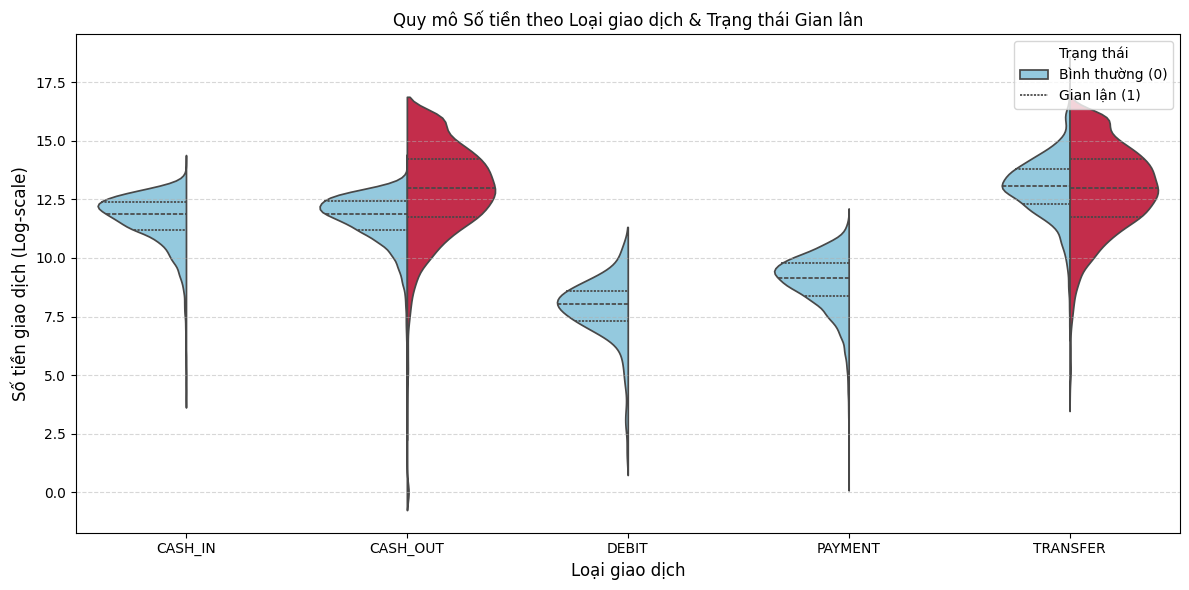

In [51]:
plt.figure(figsize=(12,6))
sns.violinplot(data=balanced_df, x='type', y=np.log1p(balanced_df['amount']),
               hue='isFraud', split=True, palette={0: "skyblue", 1: "crimson"}, inner='quartile')
plt.title('Quy mô Số tiền theo Loại giao dịch & Trạng thái Gian lân')
plt.xlabel('Loại giao dịch', fontsize=12)
plt.ylabel('Số tiền giao dịch (Log-scale)',fontsize=12)
plt.grid(axis='y', linestyle='--',alpha=0.5)
plt.legend(title='Trạng thái', loc='upper right', labels=['Bình thường (0)','Gian lận (1)'])

plt.tight_layout()
plt.show()

Phân tích 3 biến isFraud + type + amount cho thấy tội phạm không có sự ưu tiên về quy mô giữa hai khẩu;chúng tham lam tối đa ở cả hai bước để đảm bảo không để lại số dư thừa. 

Tuy nhiên, về mặt quản trị:

Khâu TRANSFER là nơi cần áp dụng các mô hình AI Predictive (dự báo) để chặn giao dịch từ đầu.

Khâu CASH_OUT là chốt chặn cuối cùng nơi ngân hàng có thể phối hợp với các điểm rút tiền/đại lý để thực hiện xác thực sinh trắc học (như QĐ 2345 của NHNN Việt Nam).

Biến: isFraud + isFlaggedFraud + amount + type

In [52]:
# Lấy các giao dịch gian lận
actual_frauds = balanced_df[balanced_df['isFraud'] == 1].copy()

In [53]:
from matplotlib.ticker import FuncFormatter

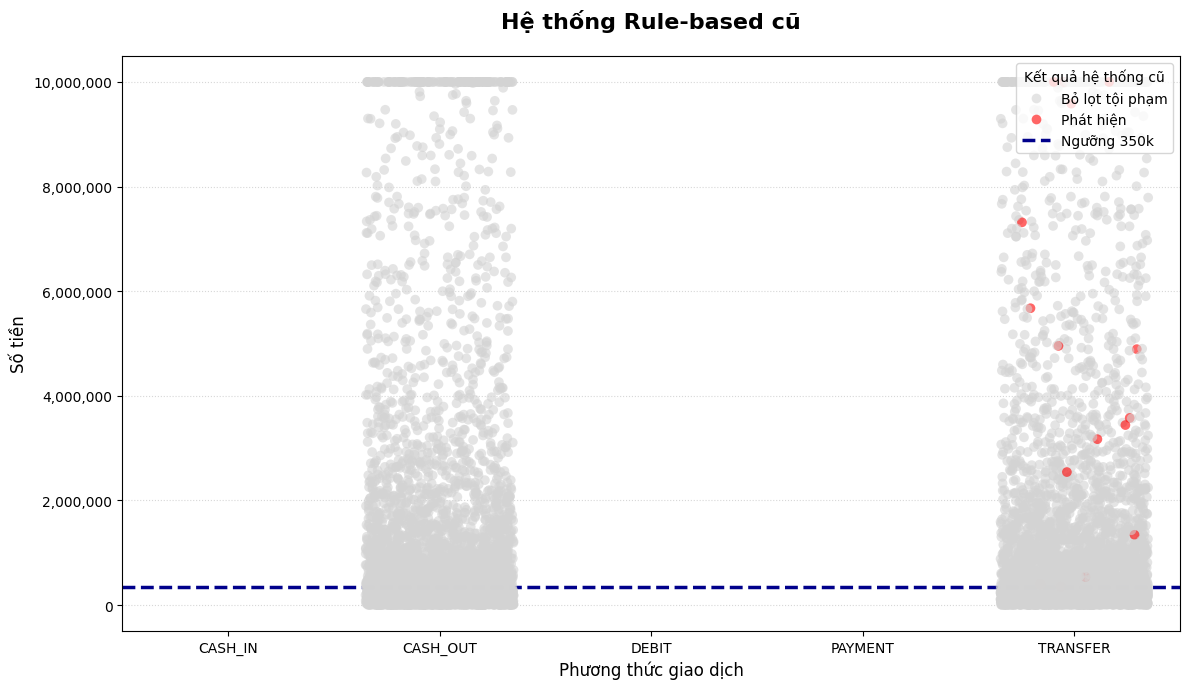

In [54]:
# Biểu đồ phân tán để trực quan
plt.figure(figsize=(12,7))
sns.stripplot(data=actual_frauds, x='type', y='amount', hue='isFlaggedFraud',
              palette={0: 'lightgray', 1: 'red'}, jitter=0.35, alpha=0.6,size=7)


plt.axhline(y=353874, color='darkblue', linestyle='--', linewidth=2.5, label='Ngưỡng báo động cũ: 353874')

plt.title('Hệ thống Rule-based cũ', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Phương thức giao dịch', fontsize=12)
plt.ylabel('Số tiền', fontsize=12)

formatter = FuncFormatter(lambda y, pos: f"{y:,.0f}")
plt.gca().yaxis.set_major_formatter(formatter)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Bỏ lọt tội phạm', 'Phát hiện', 'Ngưỡng 350k'],
           title='Kết quả hệ thống cũ', loc='upper right', frameon=True)

plt.grid(axis='y', linestyle=':',alpha=0.5)
plt.tight_layout()
plt.show()

In [55]:
report = pd.crosstab(actual_frauds['type'], actual_frauds['isFlaggedFraud'])
report.columns = ['Bỏ lọt', 'Phát hiện']
print(report)

          Bỏ lọt  Phát hiện
type                       
CASH_OUT    4116          0
TRANSFER    4081         16


Hệ thống cũ (isFlaggedFraud=1) chỉ báo còi khi thỏa mãn ĐỒNG THỜI 2 điều kiện: type = TRANSFER VÀ amount > 353874. Chỉ cần tội phạm đổi sang CASH_OUT hoặc chuyển 199.999, hệ thống lập tức tê liệt → cần dung đến Machine Learning.


In [60]:
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32852 entries, 0 to 32851
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   step              32852 non-null  int16   
 1   type              32852 non-null  category
 2   amount            32852 non-null  float32 
 3   nameOrig          32852 non-null  object  
 4   oldbalanceOrg     32852 non-null  float32 
 5   newbalanceOrig    32852 non-null  float32 
 6   nameDest          32852 non-null  object  
 7   oldbalanceDest    32852 non-null  float32 
 8   newbalanceDest    32852 non-null  float32 
 9   isFraud           32852 non-null  int8    
 10  isFlaggedFraud    32852 non-null  int8    
 11  amount_segment    32836 non-null  category
 12  dest_type         32852 non-null  object  
 13  hour_of_day       32852 non-null  int16   
 14  dest_has_history  32852 non-null  object  
dtypes: category(2), float32(5), int16(2), int8(2), object(4)
memory usage:

Biến: isFraud + orig_error + dest_error:

In [63]:
# Biến Sai số nguồn: Số dư cũ - Số tiền chuyển - Số dư mới = 0 -> True
balanced_df['org_error'] = balanced_df['oldbalanceOrg'] - balanced_df['amount'] - balanced_df['newbalanceOrig']

In [62]:
# Biến Sai số đích: Số dư cũ + Số tiền nhận - Số dư mới = 0 --> True
balanced_df['dest_error'] = balanced_df['oldbalanceDest'] + balanced_df['amount'] - balanced_df['newbalanceDest']

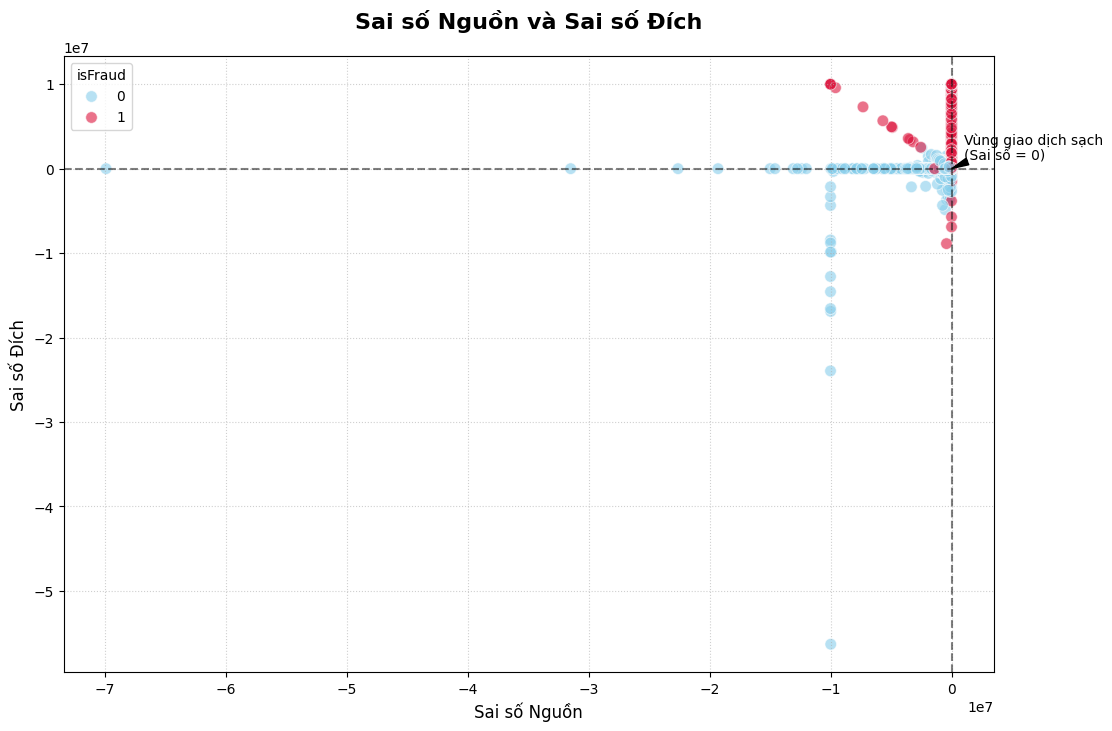

In [64]:
# Scatter Plot 2D
plt.figure(figsize=(12, 8))

sns.scatterplot(data=balanced_df, x= 'org_error', y='dest_error', hue= 'isFraud',
                palette= {0: 'skyblue', 1: 'crimson'}, alpha=0.6, s= 70, edgecolor= 'w')

plt.axhline(0, color= 'black', linestyle= '--', alpha= 0.5)
plt.axvline(0, color= 'black', linestyle= '--', alpha= 0.5)

plt.title('Sai số Nguồn và Sai số Đích', fontsize= 16, fontweight= 'bold', pad= 20)
plt.xlabel('Sai số Nguồn', fontsize= 12)
plt.ylabel('Sai số Đích', fontsize= 12)

plt.annotate('Vùng giao dịch sạch\n(Sai số = 0)', xy= (0, 0), xytext= (1e6, 1e6),
             arrowprops= dict(facecolor= 'black', shrink= 0.05, width= 1, headwidth= 5))

plt.grid(True, linestyle= ':', alpha= 0.6)
plt.show()

Ta thấy các chấm màu xanh tụ lại một điểm và tạo thành một dải hẹp ngay tại gốc tại độ --> người dùng bình thường luôn tuân thủ logic số dư ngân hàng

Ngược lại các điểm màu đỏ bắn văng ra khỏi gốc tạo độ, tạo thành những vệt đỏ --> lợi dụng hoặc tạo ra các kịch bản thực thi phi logic mà hệ thống kiểm soát tĩnh không thể đối soát kịp thời

# Kết luận EDA


Từ toàn bộ EDA, có thể rút ra mô hình hành vi gian lận:

-Tập trung vào TRANSFER,CASH_OUT

-Giá trị giao dịch lớn

-Hoạt động liên tục (không theo thời gian sinh học)

-Nhắm vào tài khoản nhận “rỗng” hoặc mới tạo

-Phá vỡ logic số dư để qua mặt hệ thống kiểm soát

-Không bị phát hiện bởi rule-based system